# Example of a joint causal model that combines a staggered treatment adoption model (in the spirit of Callaway and Sant’Anna) with IV estimation approach. Implementation in Probabilistic Programming (PP) using NumPyro

*Hugo Storm, Sep 2029*

___
### Aims of the notebook

- Show how that it is possible to have two different causal models in the same probabilistic programming model

____

### Outline of the notebook:






In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from numpyro.infer import Predictive
import numpyro
import jax
import jax.random as random

import jax.numpy as jnp
import numpyro.distributions as dist
import arviz as az

import numpyro
import numpyro.distributions as dist
from numpyro.diagnostics import print_summary
from numpyro.infer import MCMC, NUTS, Predictive

import statsmodels.api as sm
import statsmodels.formula.api as smf

from csdid.att_gt import ATTgt
import pandas as pd

from statsmodels.sandbox.regression.gmm import IV2SLS

rng_key = random.PRNGKey(0)

## Data Generating process




$Y_{it} \sim \mathcal{N}(\mu_{it}, \sigma_Y)$

$\mu_{it}=\alpha_i+\phi_t+D_{it}\,ATT(G_i,t)+E_i\,\beta^E+U_i \, \beta^U $ 

$E_i \sim \mathcal{N}(\mu^E, \sigma_E)$

$\mu^E = a^E + b^E_Z  Z_i + b^E_U  U_i$

$U_i \sim \mathcal{N}(0,1)$

With priors:

$\alpha_i, \phi_t, ATT(g,t),\beta^E, \beta^U  \sim \mathcal{N}(0,1)$

$\sigma_E, \sigma_Y \sim HalfNormal(1)$


Where $Y_{it}$ is the outcome for individual \(i\) at time \(t\), $g$ is the first treatment period for individual $i$, $ATT(g,t)$ are the group-time average treatment effects, that differ for each group \(g\) and time period \(t\). $D_{it}$ is the treatment indicator for individual $i$ at time $t$. 

$E_i$ is an observed endogenous variable that is affected by the latent variable $U_i$, which also affects the outcome $Y_{it}$. The model assumes that we have a valid instrument $Z_i$ for $E_i$, which is not affecting the outcome $Y_{it}$. 

*As an example: $Y_{it}$ could be land use, e.g. forest area in cell $i$ in time $t$, $D_{it}$ could be an indicated for protected areas, $E_i$ could a measure of available infrastructure quality, and $U_i$ could be a latent variable for the expected return for deforestation. The endogeneity could reflect that fact that infrastructure quality $E_i$ might be determined by the expected return for deforestation $U_i$, which also affects the outcome $Y_{it}$. The instrument $Z_i$ would be a instrument for infrastructure quality $E_i$ that is not directly affecting land use $Y_{it}$.*

In [35]:
num_t = 5 # number of time periods
num_n = 1000 # number of individuals

# Create instrument Z
Z = np.random.normal(size=(num_n))

# Define a (NxT,) dimensional treatment assignment vector D, 
# first N rows are for period t=0, all or none treated
# remaining (num_t-1xN) rows are for period t=1,...,num_t, with a random assignment of treatment
D_t = np.random.binomial(1, 0.2, size=(num_n,num_t-1))
D = jnp.concatenate([jnp.zeros((num_n, 1)), D_t], axis=1)

# Take the cumsum such that treatment is irreversible, and clip at 1
D = jnp.clip(jnp.cumsum(D, axis=1), 0, 1)
D = jnp.array(D, dtype=jnp.int32)
D_flat = D.flatten()
print("Shape of the flattened treatment assignment matrix D:", D_flat.shape)

# Create an (NxT,) index for the individuals
I = jnp.repeat(np.arange(num_n), num_t) 
I = jnp.array(I, dtype=jnp.int32) 
print("Shape of the individual index I:", I.shape)

# Create an (NxT,) index for the time periods
T = jnp.tile(jnp.arange(num_t), num_n)
T = jnp.array(T, dtype=jnp.int32)
print("Shape of the time index T:", T.shape)

# Determine the first period of treatment for each individual
D_first = jnp.argmax(D, axis=1)  # This will give the index of the first occurrence of treatment for each individual
D_first_flat = jnp.repeat(D_first, num_t)  # Repeat for each time period for each individual
D_first_flat = jnp.array(D_first_flat, dtype=jnp.int32)
print("Shape of the flattened first treatment period index D_first_flat:", D_first_flat.shape)

data = pd.DataFrame({
    'individual': I,
    'time': T,
    'treatment': D_flat,
    'first_treatment': D_first_flat,
    'Z': Z[I],
})

# Get list with unique groups and unique time periods
unique_groups = np.sort(data['first_treatment'].unique())
unique_times = np.sort(data['time'].unique())

data.head(20)  # Show the first 10 rows of the DataFrame

Shape of the flattened treatment assignment matrix D: (5000,)
Shape of the individual index I: (5000,)
Shape of the time index T: (5000,)
Shape of the flattened first treatment period index D_first_flat: (5000,)


,individual,time,treatment,first_treatment,Z
0,0,0,0,1,-1.639455
1,0,1,1,1,-1.639455
2,0,2,1,1,-1.639455
3,0,3,1,1,-1.639455
4,0,4,1,1,-1.639455
5,1,0,0,0,1.167614
6,1,1,0,0,1.167614
7,1,2,0,0,1.167614
8,1,3,0,0,1.167614
9,1,4,0,0,1.167614


## Define DGP in code

In [ ]:
def model_dgp(num_n, num_t, D, D_first, T, I, Z, E=None, Y=None):
    
    ######################
    # IV model part
    ######################
    # Prior for latent/unobserved variable U
    U = numpyro.sample('U', dist.Normal(0, 1).expand([Z.shape[0]]))
    
    # Prior for coefficients for the E model
    aE = numpyro.sample('aE', dist.Normal(0, 1))
    bE_Z = numpyro.sample('bE_Z', dist.Normal(0, 1))
    bE_U = numpyro.sample('bE_U', dist.Normal(0, 1))
    # Mean of E, given instrument Z
    mu_E =  aE + bE_Z * Z + bE_U * U
    # Prior for std of E
    sigma_E = numpyro.sample('sigma_E', dist.HalfNormal(1))
    # Sample E from its distribution, given Z
    E = numpyro.sample('E', dist.Normal(mu_E, sigma_E), obs=E)
    
    # Prior for coefficients for the Y model
    bY_E = numpyro.sample('bY_E', dist.Normal(0, 1))
    bY_U = numpyro.sample('bY_U', dist.Normal(0, 1))
    
    ######################
    # DiD model part
    ######################
    # Define the group time average treatment effect (ATT(g,t)) for each group and time period
    ATT = numpyro.sample("ATT", dist.Normal(0.0, 1.0).expand([num_t-1, num_t-1]))
    # Add a vector of zeros for the untreated group (g=0) to the ATT matrix
    ATT = jnp.concatenate([jnp.zeros((1, num_t-1)), ATT], axis=0)
    # Add a vector of zeros for the first time period (t=0) to the ATT matrix
    ATT = jnp.concatenate([jnp.zeros((num_t, 1)), ATT], axis=1)
    assert ATT.shape == (num_t, num_t), f"ATT shape is {ATT.shape}, expected {(num_t, num_t)}"

    # Define prior of individual effects
    alpha = numpyro.sample("alpha", dist.Normal(0.0, 1.0).expand([num_n]))
    # Define prior of temporal effects
    phi = numpyro.sample("phi", dist.Normal(0.0, 1.0).expand([num_t]))
    
    ######################
    # Model the outcome 
    ######################
    # Define prior of the standard deviation of the outcome variable
    y_sigma = numpyro.sample("y_sigma", dist.HalfNormal(1.0))
    
    # Define deterministics part of the outcome variable
    y_mean = alpha[I] + phi[T] + D*ATT[D_first, T] + bY_E * E[I] + bY_U * U[I]

    # Define the outcome variable
    numpyro.sample("Y", dist.Normal(y_mean, y_sigma), obs=Y)

In [77]:
model_fn = model_dgp
    
# Sample for the DGP
rng_key,_ = random.split(rng_key)

prior_predictive = Predictive(model_fn,num_samples=1,)

prior_samples = prior_predictive(rng_key, num_n=num_n, 
                                 num_t=num_t, D=D_flat, 
                                 D_first=D_first_flat, 
                                 Z=Z, T=T, I=I)
prior_samples.keys()

Y_syn = prior_samples["Y"][0]
E_syn = prior_samples["E"][0]
U_syn = prior_samples["U"][0]
print("Shape of the synthetic outcome variable Y:", Y_syn.shape)
print("Shape of the synthetic error variable E:", E_syn.shape)
print("Shape of the synthetic unobserved variable U:", U_syn.shape)

ATT_true = prior_samples["ATT"][0]
print("Shape of the true treatment effect ATT:", ATT_true.shape)

bY_E_true = prior_samples['bY_E'][0]

print("True ATT(g,t) matrix:")
print(ATT_true)

Shape of the synthetic outcome variable Y: (5000,)
Shape of the synthetic error variable E: (1000,)
Shape of the synthetic unobserved variable U: (1000,)
Shape of the true treatment effect ATT: (4, 4)
True ATT(g,t) matrix:
[[-1.419475   -0.50451434 -1.1791469   1.337924  ]
 [ 0.4590468  -0.2122841  -0.29970998 -0.7496662 ]
 [-0.06094865  0.5413854   0.41710475 -0.7497937 ]
 [-1.3878081   0.62683284 -0.49414584 -0.43565717]]


In [78]:
bY_E_true = prior_samples['bY_E'][0]

In [79]:
rng_key, rng_key_ = random.split(rng_key)
kernel = NUTS(model_fn)
mcmc = MCMC(kernel, num_samples=500, num_warmup=500, num_chains=1)
mcmc.run(rng_key_, num_n=num_n, num_t=num_t, 
         D=data['treatment'].values, D_first=data['first_treatment'].values, 
         T=data['time'].values, I=data['individual'].values, 
         Y=Y_syn, Z=Z, E=E_syn)
post_samples = mcmc.get_samples()
azMCMC = az.from_numpyro(mcmc)

sample: 100%|██████████| 1000/1000 [00:34<00:00, 28.98it/s, 31 steps of size 1.80e-01. acc. prob=0.85] 


In [81]:
mcmc.print_summary()


                mean       std    median      5.0%     95.0%     n_eff     r_hat
  ATT[0,0]     -1.49      0.10     -1.48     -1.65     -1.33    487.87      1.00
  ATT[0,1]     -0.74      0.11     -0.74     -0.92     -0.57    515.11      1.00
  ATT[0,2]     -1.31      0.10     -1.32     -1.46     -1.14    415.58      1.00
  ATT[0,3]      1.31      0.10      1.31      1.16      1.49    435.61      1.00
  ATT[1,0]     -0.03      0.99      0.06     -1.52      1.66   1165.89      1.00
  ATT[1,1]     -0.40      0.12     -0.40     -0.60     -0.23    443.96      1.00
  ATT[1,2]     -0.49      0.12     -0.49     -0.70     -0.34    522.32      1.00
  ATT[1,3]     -0.75      0.12     -0.75     -0.95     -0.58    455.81      1.00
  ATT[2,0]      0.01      0.94      0.01     -1.42      1.64   1436.53      1.00
  ATT[2,1]      0.02      1.07      0.00     -1.70      1.87   1054.05      1.00
  ATT[2,2]      0.38      0.11      0.38      0.20      0.57    659.22      1.00
  ATT[2,3]     -0.80      0

## Estimate statsmodels 2SLS model for comparison

In [82]:
mod = IV2SLS(Y_syn, np.hstack([np.ones((num_n*num_t, 1)),E_syn[I][:,None]]), 
             instrument=np.hstack([np.ones((num_n*num_t, 1)),Z[I][:,None]]))    # Describe model
res = mod.fit()  
print(res.summary()) 

                          IV2SLS Regression Results                           
Dep. Variable:                      y   R-squared:                       0.222
Model:                         IV2SLS   Adj. R-squared:                  0.222
Method:                     Two Stage   F-statistic:                     176.4
                        Least Squares   Prob (F-statistic):           1.36e-39
Date:                Wed, 16 Sep 2026                                         
Time:                        09:41:02                                         
No. Observations:                5000                                         
Df Residuals:                    4998                                         
Df Model:                           1                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.4580      0.034    -13.666      0.0

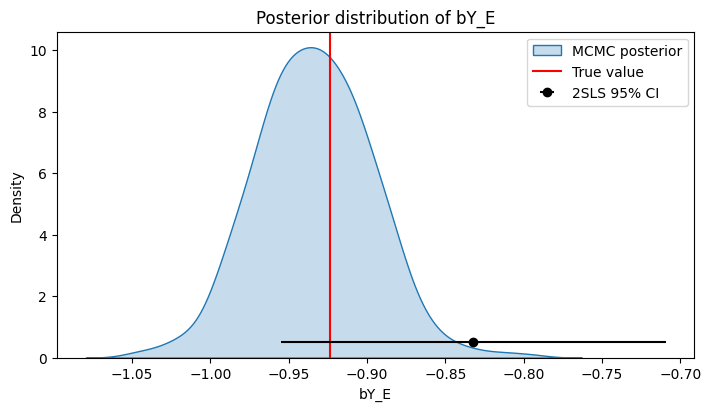

In [83]:
# Plot results using arviz
import seaborn as sns
plt.rcParams['figure.constrained_layout.use'] = True

posterior_bY_E = np.asarray(azMCMC.posterior['bY_E'].values.flatten())

fig, ax = plt.subplots(figsize=(7, 4))
sns.kdeplot(posterior_bY_E, fill=True, ax=ax, label='MCMC posterior')

ax.axvline(
    float(bY_E_true),
    color='red',
    linestyle='-',
    label='True value'
)

# Add 2sls confidence interval
ax.errorbar(x=res.params[1], y=0.5, xerr=1.96*res.bse[1], fmt='o', color='black', label='2SLS 95% CI')


ax.set_title('Posterior distribution of bY_E')
ax.set_xlabel('bY_E')
ax.set_ylabel('Density')
ax.legend()
plt.show()


## Estimate did model for comparison

In [84]:
# Add the synthetic outcome variable to the data DataFrame
data['Y'] = Y_syn
data

,individual,time,treatment,first_treatment,Z,Y
0,0,0,0,1,-1.639455,-2.313930
1,0,1,1,1,-1.639455,-3.225259
2,0,2,1,1,-1.639455,-3.363310
3,0,3,1,1,-1.639455,-0.024476
4,0,4,1,1,-1.639455,1.125987
...,...,...,...,...,...,...
4995,999,0,0,1,0.623246,-2.185703
4996,999,1,1,1,0.623246,-2.956978
4997,999,2,1,1,0.623246,-1.008928
4998,999,3,1,1,0.623246,-1.152674


In [85]:
out = ATTgt(yname = "Y",
              gname = "first_treatment",
              idname = "individual",
              tname = "time",
              xformla = f"Y~1",
              data = data,
              ).fit(est_method = 'dr')
df_out = out.summ_attgt().summary2

df_out['true_ATT'] = ATT_true.flatten()
df_out.set_index(['Group', 'Time'], inplace=True)

df_out

ATT(g, t)  Post  Std. Error  [95% Pointwise  Conf. Band]     \
Group Time                                                                
1     1       -1.5060     1      0.1315         -1.8804      -1.1317  *   
      2       -0.8194     1      0.1260         -1.1781      -0.4607  *   
      3       -1.3644     1      0.1230         -1.7145      -1.0143  *   
      4        1.2674     1      0.1304          0.8963       1.6385  *   
2     1        0.0407     0      0.1394         -0.3562       0.4376      
      2       -0.5388     1      0.1296         -0.9078      -0.1698  *   
      3       -0.6090     1      0.1518         -1.0409      -0.1770  *   
      4       -0.8752     1      0.1591         -1.3279      -0.4224  *   
3     1        0.1098     0      0.1506         -0.3188       0.5383      
      2       -0.1400     0      0.1411         -0.5417       0.2616      
      3        0.4296     1      0.1327          0.0520       0.8073  *   
      4       -0.7559     1      0.1345         -1.1387      -0.3732  *   
4     1        0.0456     0      0.1387         -0.3491       0.4404      
      2       -0.1374     0      0.1407         -0.5379       0.2631      
      3        0.1201     0      0.1753         -0.3790       0.6192      
      4       -0.3513     1      0.1519         -0.7836       0.0810      

            true_ATT  
Group Time            
1     1    -1.419475  
      2    -0.504514  
      3    -1.179147  
      4     1.337924  
2     1     0.459047  
      2    -0.212284  
      3    -0.299710  
      4    -0.749666  
3     1    -0.060949  
      2     0.541385  
      3     0.417105  
      4    -0.749794  
4     1    -1.387808  
      2     0.626833  
      3    -0.494146  
      4    -0.435657

In [86]:
# Calculate the mean of the ATT samples across all MCMC samples
ATT_mcmc_mean = jnp.mean(post_samples['ATT'], axis=0)
ATT_mcmc_std = jnp.std(post_samples['ATT'], axis=0)

# Add the mean and standard deviation of the ATT samples to the output DataFrame
df_out['ATT_mcmc_mean'] = ATT_mcmc_mean.flatten()
df_out['ATT_mcmc_std'] = ATT_mcmc_std.flatten()

/tmp/ipykernel_488408/2237335465.py:56: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


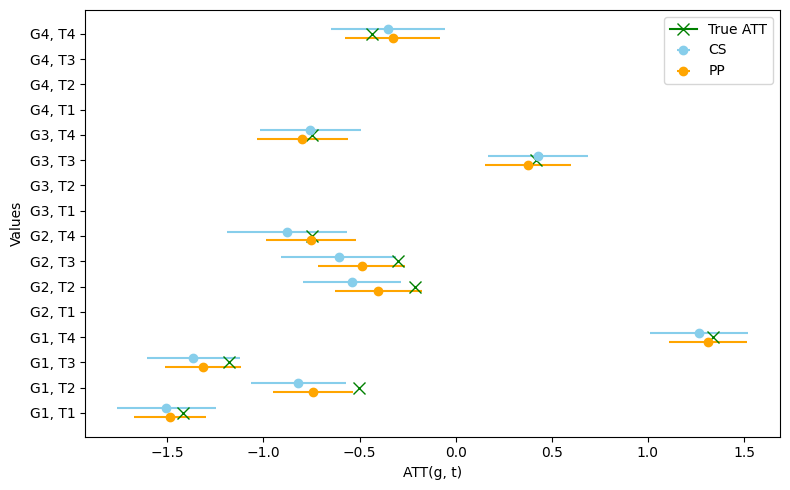

In [87]:
idx_g = np.sort(df_out.index.get_level_values('Group').unique())
idx_t = np.sort(df_out.index.get_level_values('Time').unique())

# Setup numerical X positions and bar width
x = np.arange(df_out.shape[0])  # Numerical indices [0, 1, 2, 3]
width = 0.35  # Width of each bar

categories = [f"G{g}, T{t}" for g in idx_g for t in idx_t]
x = np.arange(len(categories))  # Numerical indices for the categories

fig, ax = plt.subplots(figsize=(8, 5))

# Plot Group 1 (shifted to the left by width/2)
i=0
for g in idx_g:
    for t in idx_t:
        
        # Exclude for plotting cases where t < g, as ATT(g, t) is not defined for those cases
        if t>=g:
            ax.errorbar(
                df_out.loc[(g, t), 'ATT(g, t)'] ,
                x[i] + width / 2,
                xerr=1.96*df_out.loc[(g, t), 'Std. Error'],
                fmt='o',
                color="skyblue",
                label='CS' if i == 0 else "",  # Only add label for the first point
            )
            ax.errorbar(
                df_out.loc[(g, t), 'ATT_mcmc_mean'] ,
                x[i] - width / 2,
                xerr=1.96*df_out.loc[(g, t), 'ATT_mcmc_std'],
                fmt='o',
                color="orange",
                label='PP' if i == 0 else "",  # Only add label for the first point
            )
            # Add a true value marker for the ATT(g, t) from the DGP
            ax.plot(
                df_out.loc[(g, t), 'true_ATT'],
                x[i],
                marker='x',
                color='green',
                markersize=8,
                label='True ATT' if i == 0 else "",  # Only add label for the first point
            )
            
        i+=1

# Map the numerical X indices back to your String Categories
ax.set_yticks(x)
ax.set_yticklabels(categories)

ax.set_ylabel("Values")
ax.set_xlabel("ATT(g, t)")
ax.legend()

plt.tight_layout()
plt.show()

## Part B: Extent the model by considering connection between the two parts

The advantage of a joint model is that we can connect the two parts of the model, as one simple example consider we expect that $ATT$ varies by "E_i$, i.e. that the treatment effect 
is heterogeneous by the observed endogenous variable $E_i$. 

$Y_{it} \sim \mathcal{N}(\mu_{it}, \sigma_Y)$

$\mu_{it}=\alpha_i+\phi_t+D_{it}\,ATT(G_i,t)+E_i\,\beta^E+U_i \, \beta^U $ 

$ATT(g,t) \sim \mathcal{N}(\beta_E^{ATT} \,E_i,1)$


$E_i \sim \mathcal{N}(\mu^E, \sigma_E)$

$\mu^E = a^E + b^E_Z  Z_i + b^E_U  U_i$

$U_i \sim \mathcal{N}(0,1)$

With priors:

$\alpha_i, \phi_t, ATT(g,t),\beta^E, \beta^U  \sim \mathcal{N}(0,1)$

$\sigma_E, \sigma_Y \sim HalfNormal(1)$

In [209]:
num_t = 5 # number of time periods
num_n = 1000 # number of individuals

# Create instrument Z
Z = np.random.normal(size=(num_n))

# Define a (NxT,) dimensional treatment assignment vector D, 
# first N rows are for period t=0, all or none treated
# remaining (num_t-1xN) rows are for period t=1,...,num_t, with a random assignment of treatment
D_t = np.random.binomial(1, 0.2, size=(num_n,num_t-1))
D = jnp.concatenate([jnp.zeros((num_n, 1)), D_t], axis=1)

# Take the cumsum such that treatment is irreversible, and clip at 1
D = jnp.clip(jnp.cumsum(D, axis=1), 0, 1)
D = jnp.array(D, dtype=jnp.int32)
D_flat = D.flatten()
print("Shape of the flattened treatment assignment matrix D:", D_flat.shape)

# Create an (NxT,) index for the individuals
I = jnp.repeat(np.arange(num_n), num_t) 
I = jnp.array(I, dtype=jnp.int32) 
print("Shape of the individual index I:", I.shape)

# Create an (NxT,) index for the time periods
T = jnp.tile(jnp.arange(num_t), num_n)
T = jnp.array(T, dtype=jnp.int32)
print("Shape of the time index T:", T.shape)

# Determine the first period of treatment for each individual
D_first = jnp.argmax(D, axis=1)  # This will give the index of the first occurrence of treatment for each individual
D_first_flat = jnp.repeat(D_first, num_t)  # Repeat for each time period for each individual
D_first_flat = jnp.array(D_first_flat, dtype=jnp.int32)
print("Shape of the flattened first treatment period index D_first_flat:", D_first_flat.shape)

data = pd.DataFrame({
    'individual': I,
    'time': T,
    'treatment': D_flat,
    'first_treatment': D_first_flat,
    'Z': Z[I],
})

# Get list with unique groups and unique time periods
unique_groups = np.sort(data['first_treatment'].unique())
unique_times = np.sort(data['time'].unique())

data.head(20)  # Show the first 10 rows of the DataFrame

Shape of the flattened treatment assignment matrix D: (5000,)
Shape of the individual index I: (5000,)
Shape of the time index T: (5000,)
Shape of the flattened first treatment period index D_first_flat: (5000,)


,individual,time,treatment,first_treatment,Z
0,0,0,0,1,-0.884493
1,0,1,1,1,-0.884493
2,0,2,1,1,-0.884493
3,0,3,1,1,-0.884493
4,0,4,1,1,-0.884493
5,1,0,0,0,0.470219
6,1,1,0,0,0.470219
7,1,2,0,0,0.470219
8,1,3,0,0,0.470219
9,1,4,0,0,0.470219


In [ ]:
def model_dgp_treat_heterogeneity(num_n, num_t, D, D_first, T, I, Z, E=None, Y=None):
    
    ######################
    # IV model part
    ######################
    # Prior for latent/unobserved variable U
    U = numpyro.sample('U', dist.Normal(0, 1).expand([Z.shape[0]]))
    
    # Prior for coefficients for the E model
    aE = numpyro.sample('aE', dist.Normal(0, 1))
    bE_Z = numpyro.sample('bE_Z', dist.Normal(0, 1))
    bE_U = numpyro.sample('bE_U', dist.Normal(0, 1))
    # Mean of E, given instrument Z
    mu_E =  aE + bE_Z * Z + bE_U * U
    # Prior for std of E
    sigma_E = numpyro.sample('sigma_E', dist.HalfNormal(1))
    # Sample E from its distribution, given Z
    E = numpyro.sample('E', dist.Normal(mu_E, sigma_E), obs=E)
    
    # Prior for coefficients for the Y model
    bY_E = numpyro.sample('bY_E', dist.Normal(0, 1))
    bY_U = numpyro.sample('bY_U', dist.Normal(0, 1))
    
    ######################
    # DiD model part
    ######################
    # Define the group time average treatment effect (ATT(g,t)) for each group and time period
    ATT = numpyro.sample("ATT", dist.Normal(0.0, 1.0).expand([num_t-1, num_t-1]))
    # Add a vector of zeros for the untreated group (g=0) to the ATT matrix
    ATT = jnp.concatenate([jnp.zeros((1, num_t-1)), ATT], axis=0)
    # Add a vector of zeros for the first time period (t=0) to the ATT matrix
    ATT = jnp.concatenate([jnp.zeros((num_t, 1)), ATT], axis=1)
    assert ATT.shape == (num_t, num_t), f"ATT shape is {ATT.shape}, expected {(num_t, num_t)}"

    # Define prior of individual effects
    alpha = numpyro.sample("alpha", dist.Normal(0.0, 1.0).expand([num_n]))
    # Define prior of temporal effects
    phi = numpyro.sample("phi", dist.Normal(0.0, 1.0).expand([num_t]))
    
    ######################
    # Model the outcome 
    ######################
    # Define prior of the standard deviation of the outcome variable
    y_sigma = numpyro.sample("y_sigma", dist.HalfNormal(1.0))
    
    # Prior for the coefficient of the interaction term between treatment and E
    bATT_E = numpyro.sample('bATT_E', dist.Normal(0, 1))
    
    # Define deterministics part of the outcome variable
    # y_mean = alpha[I] + phi[T] + D*ATT[D_first, T] + bY_E * E[I] + bY_U * U[I]
    y_mean = alpha[I] + phi[T] + D*(ATT[D_first, T]+ bATT_E * E[I]) + bY_E * E[I] + bY_U * U[I]
    # y_mean = alpha[I] + phi[T] + D*(ATT[D_first, T]+ bATT_E * Z[I]) 

    # Define the outcome variable
    numpyro.sample("Y", dist.Normal(y_mean, y_sigma), obs=Y)

In [231]:
model_fn = model_dgp_treat_heterogeneity
    
# Sample for the DGP
rng_key,_ = random.split(rng_key)

prior_predictive = Predictive(model_fn,num_samples=1,)

prior_samples = prior_predictive(rng_key, num_n=num_n, 
                                 num_t=num_t, D=D_flat, 
                                 D_first=D_first_flat, 
                                 Z=Z, T=T, I=I)
prior_samples.keys()

Y_syn = prior_samples["Y"][0]
E_syn = prior_samples["E"][0]
U_syn = prior_samples["U"][0]
print("Shape of the synthetic outcome variable Y:", Y_syn.shape)
print("Shape of the synthetic error variable E:", E_syn.shape)
print("Shape of the synthetic unobserved variable U:", U_syn.shape)

bY_E_true = prior_samples['bY_E'][0]

bATT_E_true = prior_samples['bATT_E'][0]

ATT_true = prior_samples["ATT"][0]
print("Shape of the true treatment effect ATT:", ATT_true.shape)

print("True ATT(g,t) matrix:")
print(ATT_true)

Shape of the synthetic outcome variable Y: (5000,)
Shape of the synthetic error variable E: (1000,)
Shape of the synthetic unobserved variable U: (1000,)
Shape of the true treatment effect ATT: (4, 4)
True ATT(g,t) matrix:
[[-1.3150672   0.5794532  -1.5123764  -0.08577088]
 [ 1.0594335   1.1493818  -1.8347598  -0.48137233]
 [ 1.4032217  -0.80639654  1.5834849   0.16766723]
 [ 0.24253117  0.37736967 -0.60254973  0.4288501 ]]


In [232]:
rng_key, rng_key_ = random.split(rng_key)
kernel = NUTS(model_fn)
mcmc = MCMC(kernel, num_samples=500, num_warmup=500, num_chains=1)
mcmc.run(rng_key_, num_n=num_n, num_t=num_t, 
         D=data['treatment'].values, D_first=data['first_treatment'].values, 
         T=data['time'].values, I=data['individual'].values, 
         Y=Y_syn, Z=Z, E=E_syn)
post_samples= mcmc.get_samples()
azMCMC = az.from_numpyro(mcmc)

sample: 100%|██████████| 1000/1000 [02:14<00:00,  7.41it/s, 255 steps of size 2.45e-02. acc. prob=0.91]


In [233]:
post_samples= mcmc.get_samples()
post_samples.keys()

dict_keys(['ATT', 'U', 'aE', 'alpha', 'bATT_E', 'bE_U', 'bE_Z', 'bY_E', 'bY_U', 'phi', 'sigma_E', 'y_sigma'])

In [243]:
mcmc.print_summary()


                mean       std    median      5.0%     95.0%     n_eff     r_hat
  ATT[0,0]     -1.35      0.05     -1.35     -1.43     -1.27    631.71      1.00
  ATT[0,1]      0.57      0.05      0.57      0.50      0.66    426.01      1.00
  ATT[0,2]     -1.52      0.05     -1.52     -1.62     -1.44    527.63      1.00
  ATT[0,3]     -0.11      0.06     -0.11     -0.20     -0.02    612.65      1.00
  ATT[1,0]      0.04      0.95      0.02     -1.43      1.49    739.16      1.00
  ATT[1,1]      1.24      0.05      1.24      1.16      1.33   1002.28      1.00
  ATT[1,2]     -1.79      0.05     -1.80     -1.87     -1.71   1562.62      1.00
  ATT[1,3]     -0.46      0.05     -0.46     -0.55     -0.37    790.93      1.00
  ATT[2,0]      0.02      1.03      0.03     -1.67      1.67   1481.17      1.00
  ATT[2,1]     -0.02      0.98     -0.06     -1.59      1.58    970.88      1.00
  ATT[2,2]      1.63      0.05      1.63      1.54      1.70    876.87      1.00
  ATT[2,3]      0.21      0

## Estimate statsmodels 2SLS model for comparison

In [235]:
mod = IV2SLS(Y_syn, np.hstack([np.ones((num_n*num_t, 1)),E_syn[I][:,None]]), 
             instrument=np.hstack([np.ones((num_n*num_t, 1)),Z[I][:,None]]))    # Describe model
res = mod.fit()  
print(res.summary()) 


                          IV2SLS Regression Results                           
Dep. Variable:                      y   R-squared:                       0.284
Model:                         IV2SLS   Adj. R-squared:                  0.284
Method:                     Two Stage   F-statistic:                     37.88
                        Least Squares   Prob (F-statistic):           8.12e-10
Date:                Wed, 16 Sep 2026                                         
Time:                        10:33:27                                         
No. Observations:                5000                                         
Df Residuals:                    4998                                         
Df Model:                           1                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.7945      0.086     -9.203      0.0

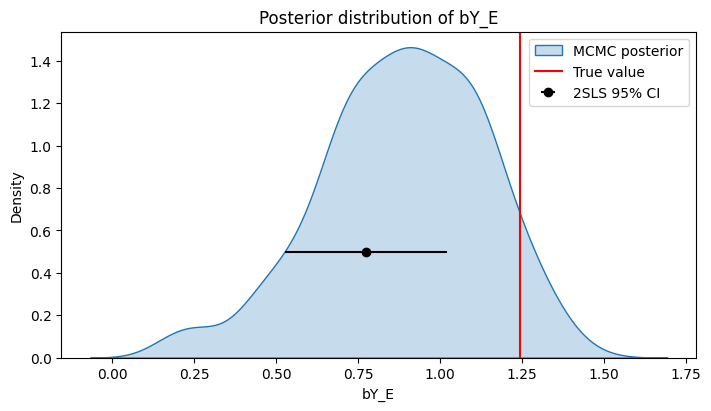

In [236]:
# Plot results using arviz
import seaborn as sns
plt.rcParams['figure.constrained_layout.use'] = True

posterior_bY_E = np.asarray(azMCMC.posterior['bY_E'].values.flatten())

fig, ax = plt.subplots(figsize=(7, 4))
sns.kdeplot(posterior_bY_E, fill=True, ax=ax, label='MCMC posterior')

ax.axvline(
    float(bY_E_true),
    color='red',
    linestyle='-',
    label='True value'
)

# Add 2sls confidence interval
ax.errorbar(x=res.params[1], y=0.5, xerr=1.96*res.bse[1], fmt='o', color='black', label='2SLS 95% CI')


ax.set_title('Posterior distribution of bY_E')
ax.set_xlabel('bY_E')
ax.set_ylabel('Density')
ax.legend()
plt.show()


## Estimate did model for comparison

In [237]:
# Add the synthetic outcome variable to the data DataFrame
data['Y'] = Y_syn
data

,individual,time,treatment,first_treatment,Z,Y
0,0,0,0,1,-0.884493,-1.575226
1,0,1,1,1,-0.884493,-3.566246
2,0,2,1,1,-0.884493,-0.118601
3,0,3,1,1,-0.884493,-2.440837
4,0,4,1,1,-0.884493,-3.676803
...,...,...,...,...,...,...
4995,999,0,0,2,-0.019888,-0.257959
4996,999,1,0,2,-0.019888,0.413639
4997,999,2,1,2,-0.019888,3.066519
4998,999,3,1,2,-0.019888,-0.981578


In [238]:
out = ATTgt(yname = "Y",
              gname = "first_treatment",
              idname = "individual",
              tname = "time",
              xformla = f"Y~1",
              data = data,
              ).fit(est_method = 'dr')
df_out = out.summ_attgt().summary2

df_out['true_ATT'] = ATT_true.flatten()
df_out.set_index(['Group', 'Time'], inplace=True)

df_out

ATT(g, t)  Post  Std. Error  [95% Pointwise  Conf. Band]     \
Group Time                                                                
1     1       -1.3152     1      0.0561         -1.4762      -1.1542  *   
      2        0.6149     1      0.0544          0.4586       0.7711  *   
      3       -1.4788     1      0.0518         -1.6275      -1.3301  *   
      4       -0.0678     1      0.0507         -0.2134       0.0777      
2     1       -0.0184     0      0.0644         -0.2032       0.1663      
      2        1.2832     1      0.0649          1.0971       1.4694  *   
      3       -1.7528     1      0.0604         -1.9261      -1.5796  *   
      4       -0.4144     1      0.0615         -0.5910      -0.2378  *   
3     1       -0.0315     0      0.0698         -0.2317       0.1687      
      2        0.0225     0      0.0668         -0.1692       0.2142      
      3        1.6580     1      0.0622          1.4794       1.8365  *   
      4        0.2359     1      0.0720          0.0293       0.4426  *   
4     1        0.0088     0      0.0748         -0.2059       0.2236      
      2       -0.0105     0      0.0738         -0.2222       0.2012      
      3        0.0090     0      0.0766         -0.2107       0.2287      
      4        0.4296     1      0.0713          0.2250       0.6342  *   

            true_ATT  
Group Time            
1     1    -1.315067  
      2     0.579453  
      3    -1.512376  
      4    -0.085771  
2     1     1.059433  
      2     1.149382  
      3    -1.834760  
      4    -0.481372  
3     1     1.403222  
      2    -0.806397  
      3     1.583485  
      4     0.167667  
4     1     0.242531  
      2     0.377370  
      3    -0.602550  
      4     0.428850

In [239]:
# Derive true ATT for the three different categories of the categorical covariate (0, 1, 2)
ATT_W_low_true = bATT_E_true * np.percentile(E_syn, 10)  + ATT_true
ATT_W_medium_true = bATT_E_true * np.percentile(E_syn, 50)  + ATT_true
ATT_W_high_true = bATT_E_true * np.percentile(E_syn, 90)  + ATT_true

df_out["ATT_W_low_true"] = ATT_W_low_true.flatten()
df_out["ATT_W_medium_true"] = ATT_W_medium_true.flatten()
df_out["ATT_W_high_true"] = ATT_W_high_true.flatten()
df_out

ATT(g, t)  Post  Std. Error  [95% Pointwise  Conf. Band]     \
Group Time                                                                
1     1       -1.3152     1      0.0561         -1.4762      -1.1542  *   
      2        0.6149     1      0.0544          0.4586       0.7711  *   
      3       -1.4788     1      0.0518         -1.6275      -1.3301  *   
      4       -0.0678     1      0.0507         -0.2134       0.0777      
2     1       -0.0184     0      0.0644         -0.2032       0.1663      
      2        1.2832     1      0.0649          1.0971       1.4694  *   
      3       -1.7528     1      0.0604         -1.9261      -1.5796  *   
      4       -0.4144     1      0.0615         -0.5910      -0.2378  *   
3     1       -0.0315     0      0.0698         -0.2317       0.1687      
      2        0.0225     0      0.0668         -0.1692       0.2142      
      3        1.6580     1      0.0622          1.4794       1.8365  *   
      4        0.2359     1      0.0720          0.0293       0.4426  *   
4     1        0.0088     0      0.0748         -0.2059       0.2236      
      2       -0.0105     0      0.0738         -0.2222       0.2012      
      3        0.0090     0      0.0766         -0.2107       0.2287      
      4        0.4296     1      0.0713          0.2250       0.6342  *   

            true_ATT  ATT_W_low_true  ATT_W_medium_true  ATT_W_high_true  
Group Time                                                                
1     1    -1.315067       -1.186273          -1.278373        -1.375384  
      2     0.579453        0.708247           0.616148         0.519136  
      3    -1.512376       -1.383582          -1.475682        -1.572693  
      4    -0.085771        0.043023          -0.049076        -0.146088  
2     1     1.059433        1.188228           1.096128         0.999116  
      2     1.149382        1.278176           1.186076         1.089065  
      3    -1.834760       -1.705966          -1.798065        -1.895077  
      4    -0.481372       -0.352578          -0.444678        -0.541689  
3     1     1.403222        1.532016           1.439916         1.342905  
      2    -0.806397       -0.677602          -0.769702        -0.866714  
      3     1.583485        1.712279           1.620180         1.523168  
      4     0.167667        0.296462           0.204362         0.107350  
4     1     0.242531        0.371325           0.279226         0.182214  
      2     0.377370        0.506164           0.414064         0.317053  
      3    -0.602550       -0.473755          -0.565855        -0.662867  
      4     0.428850        0.557644           0.465545         0.368533

In [240]:
cat_names = ["low", "medium", "high"]
# Derive the mean and standard deviation of the ATT samples for each category of the categorical covariate (0, 1, 2)
ATT_W_low = np.percentile(E_syn, 10) * post_samples['bATT_E']
ATT_W_medium = np.percentile(E_syn, 50) * post_samples['bATT_E']
ATT_W_high = np.percentile(E_syn, 90) * post_samples['bATT_E']
ATT_W_low_mean = np.mean((ATT_W_low[:,None,None]+post_samples['ATT']),axis=0)
ATT_W_medium_mean = np.mean((ATT_W_medium[:,None,None]+post_samples['ATT']),axis=0)
ATT_W_high_mean = np.mean((ATT_W_high[:,None,None]+post_samples['ATT']),axis=0)

ATT_W_low_std = np.std((ATT_W_low[:,None,None]+post_samples['ATT']),axis=0)
ATT_W_medium_std = np.std((ATT_W_medium[:,None,None]+post_samples['ATT']),axis=0)
ATT_W_high_std = np.std((ATT_W_high[:,None,None]+post_samples['ATT']),axis=0)
    

for name,arr in [["ATT_W_low_mean",ATT_W_low_mean],["ATT_W_medium_mean",ATT_W_medium_mean],["ATT_W_high_mean",ATT_W_high_mean],
                 ["ATT_W_low_std",ATT_W_low_std],["ATT_W_medium_std",ATT_W_medium_std],["ATT_W_high_std",ATT_W_high_std]]:
    aa = (pd.DataFrame(arr, index=[g+1 for g in range(num_t-1)], 
                        columns=[t+1 for t in range(num_t-1)])
                .stack().to_frame(name=name)
                .reset_index().rename(columns={'level_0': 'Group', 'level_1': 'Time'})).set_index(['Group', 'Time'])
    df_out = df_out.join(aa, how='right')
    

In [241]:
df_out

ATT(g, t)  Post  Std. Error  [95% Pointwise  Conf. Band]     \
Group Time                                                                
1     1       -1.3152     1      0.0561         -1.4762      -1.1542  *   
      2        0.6149     1      0.0544          0.4586       0.7711  *   
      3       -1.4788     1      0.0518         -1.6275      -1.3301  *   
      4       -0.0678     1      0.0507         -0.2134       0.0777      
2     1       -0.0184     0      0.0644         -0.2032       0.1663      
      2        1.2832     1      0.0649          1.0971       1.4694  *   
      3       -1.7528     1      0.0604         -1.9261      -1.5796  *   
      4       -0.4144     1      0.0615         -0.5910      -0.2378  *   
3     1       -0.0315     0      0.0698         -0.2317       0.1687      
      2        0.0225     0      0.0668         -0.1692       0.2142      
      3        1.6580     1      0.0622          1.4794       1.8365  *   
      4        0.2359     1      0.0720          0.0293       0.4426  *   
4     1        0.0088     0      0.0748         -0.2059       0.2236      
      2       -0.0105     0      0.0738         -0.2222       0.2012      
      3        0.0090     0      0.0766         -0.2107       0.2287      
      4        0.4296     1      0.0713          0.2250       0.6342  *   

            true_ATT  ATT_W_low_true  ATT_W_medium_true  ATT_W_high_true  \
Group Time                                                                 
1     1    -1.315067       -1.186273          -1.278373        -1.375384   
      2     0.579453        0.708247           0.616148         0.519136   
      3    -1.512376       -1.383582          -1.475682        -1.572693   
      4    -0.085771        0.043023          -0.049076        -0.146088   
2     1     1.059433        1.188228           1.096128         0.999116   
      2     1.149382        1.278176           1.186076         1.089065   
      3    -1.834760       -1.705966          -1.798065        -1.895077   
      4    -0.481372       -0.352578          -0.444678        -0.541689   
3     1     1.403222        1.532016           1.439916         1.342905   
      2    -0.806397       -0.677602          -0.769702        -0.866714   
      3     1.583485        1.712279           1.620180         1.523168   
      4     0.167667        0.296462           0.204362         0.107350   
4     1     0.242531        0.371325           0.279226         0.182214   
      2     0.377370        0.506164           0.414064         0.317053   
      3    -0.602550       -0.473755          -0.565855        -0.662867   
      4     0.428850        0.557644           0.465545         0.368533   

            ATT_W_low_mean  ATT_W_medium_mean  ATT_W_high_mean  ATT_W_low_std  \
Group Time                                                                      
1     1          -1.234782          -1.315362        -1.400239       0.052055   
      2           0.686963           0.606384         0.521507       0.050515   
      3          -1.403897          -1.484476        -1.569353       0.056785   
      4           0.004520          -0.076059        -0.160936       0.059334   
2     1           0.150001           0.069421        -0.015456       0.951412   
      2           1.349295           1.268716         1.183839       0.052579   
      3          -1.681633          -1.762213        -1.847089       0.053799   
      4          -0.346664          -0.427244        -0.512120       0.057517   
3     1           0.131652           0.051073        -0.033804       1.025609   
      2           0.091020           0.010441        -0.074436       0.987625   
      3           1.738248           1.657669         1.572792       0.056514   
      4           0.318134           0.237555         0.152678       0.056185   
4     1           0.045431          -0.035148        -0.120025       0.965092   
      2           0.181459           0.100880         0.016003       1.067691

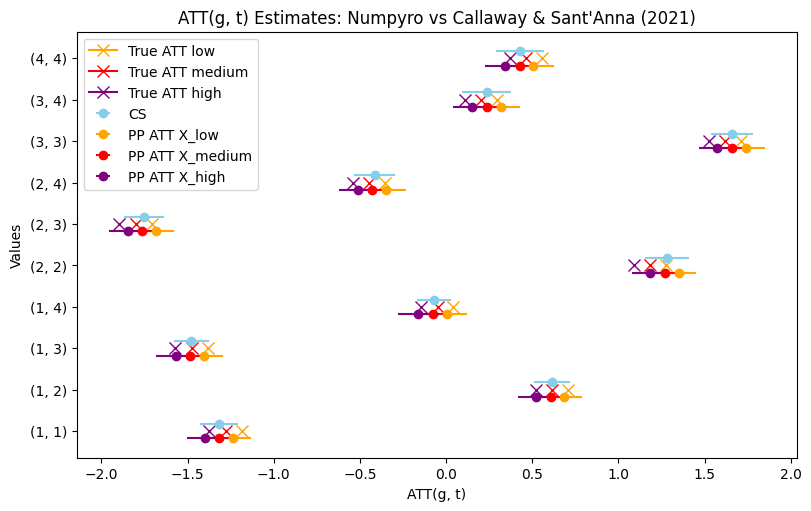

In [242]:
# Filter only cases where ATT(g, t) is not NaN and where Time >= Group
# Note it is also interesting to plot the cases where Time < Group, because the PP
# model indicates, by the large uncertainty, that those cases are not identified 
plot_only_cases_where_ATT_is_defined = True
if plot_only_cases_where_ATT_is_defined:
    df_out_not_nan = df_out[((~df_out['ATT(g, t)'].isna())) & (df_out.index.get_level_values('Time')>=df_out.index.get_level_values('Group'))]
else:
    # Use this to plot only the cases where ATT(g, t) is defined and not NaN
    df_out_not_nan = df_out[((~df_out['ATT(g, t)'].isna()))]

# Setup numerical X positions and bar width
x = np.arange(df_out_not_nan.shape[0])  # Numerical indices [0, 1, 2, 3]
width = 0.35  # Width of each bar

# categories = [f"G{g}, T{t}" for g in idx_g for t in idx_t]
categories = [(idx[0], idx[1]) for idx in df_out_not_nan.index.values]
x = np.arange(len(categories))  # Numerical indices for the categories

fig, ax = plt.subplots(figsize=(8, 5))

i=0
for idx in categories:
        
        g, t = idx
        # Check if the value is not NaN before plotting
        ax.errorbar(
            df_out.loc[(g, t), 'ATT(g, t)'] ,
            x[i] + width / 2,
            xerr=1.96*df_out.loc[(g, t), 'Std. Error'],
            fmt='o',
            color="skyblue",
            label="CS" if i == 0 else ""
        )
        colors = ["orange", "red", "purple"]
        i_offset = 0
        for cat in ['low', 'medium', 'high']:
            ax.errorbar(
                df_out.loc[(g, t), f'ATT_W_{cat}_mean'],
                # x[i] - width / 2- i_offset * 0.3,
                x[i] - width / 2,
                xerr=1.96*df_out.loc[(g, t), f'ATT_W_{cat}_std'],  
                fmt='o',
                color=colors[i_offset],
                label=f"PP ATT X_{cat}" if i == 0 else ""
            )
            
            # Add a true value marker for the ATT(g, t) from the DGP
            ax.plot(
                df_out.loc[(g, t), f'ATT_W_{cat}_true'],
                x[i],
                marker='x',
                color=colors[i_offset],
                markersize=8,
                label=f'True ATT {cat}' if i == 0 else "",  # Only add label for the first point
            )
            i_offset+=1
  
        i+=1

# Map the numerical X indices back to your String Categories
ax.set_yticks(x)
ax.set_yticklabels(categories)

ax.set_ylabel("Values")
ax.set_title("ATT(g, t) Estimates: Numpyro vs Callaway & Sant'Anna (2021)")
ax.set_xlabel("ATT(g, t)")
ax.legend()

# plt.tight_layout()
plt.show()